Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 68.2+ KB
Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
Exercise

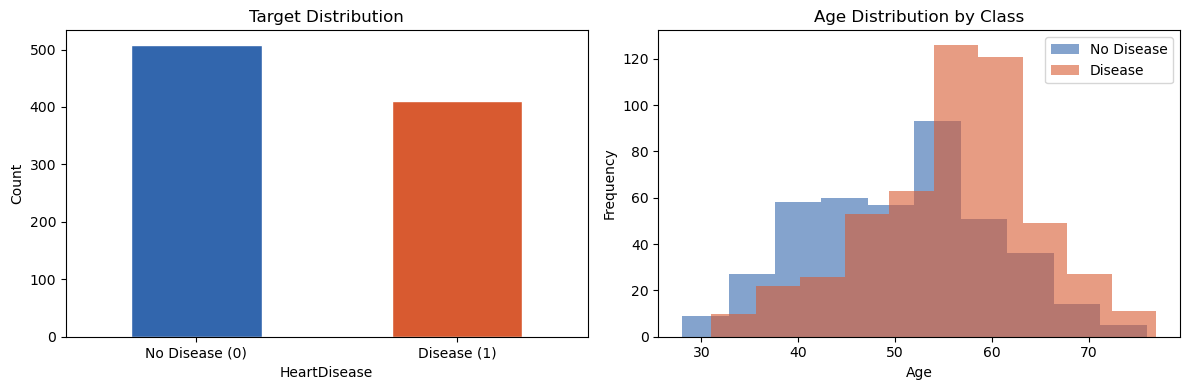

Columns after encoding:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Feature matrix shape: (918, 18)
Target shape: (918,)
Train: 734 rows  |  Test: 184 rows
Best max_depth by test accuracy: 3
  Train accuracy at best depth : 0.8542
  Test  accuracy at best depth : 0.8207


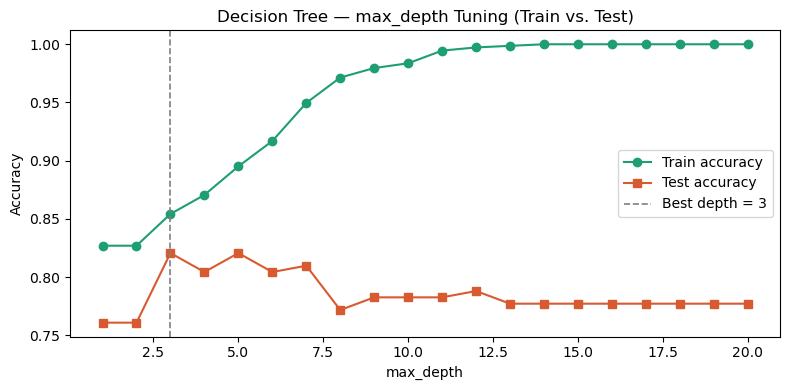

=== Decision Tree — 5-Fold Cross-Validation ===
Scores per fold : [0.8478 0.8152 0.8098 0.8415 0.8197]
Mean accuracy   : 0.8268
Std deviation   : 0.0151


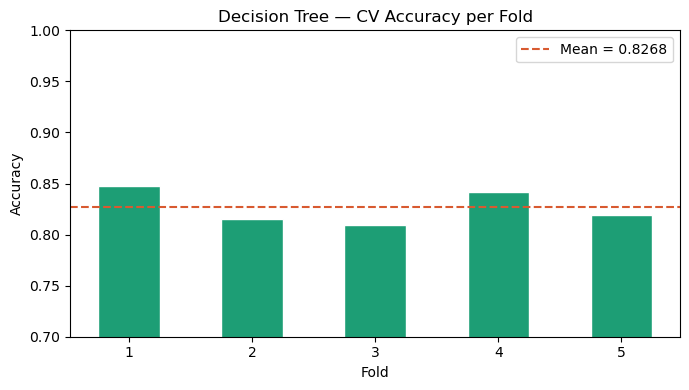

=== Decision Tree (tuned) ===
Accuracy : 0.8207
AUC-ROC  : 0.8859

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.85      0.81        82
     Disease       0.87      0.79      0.83       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184



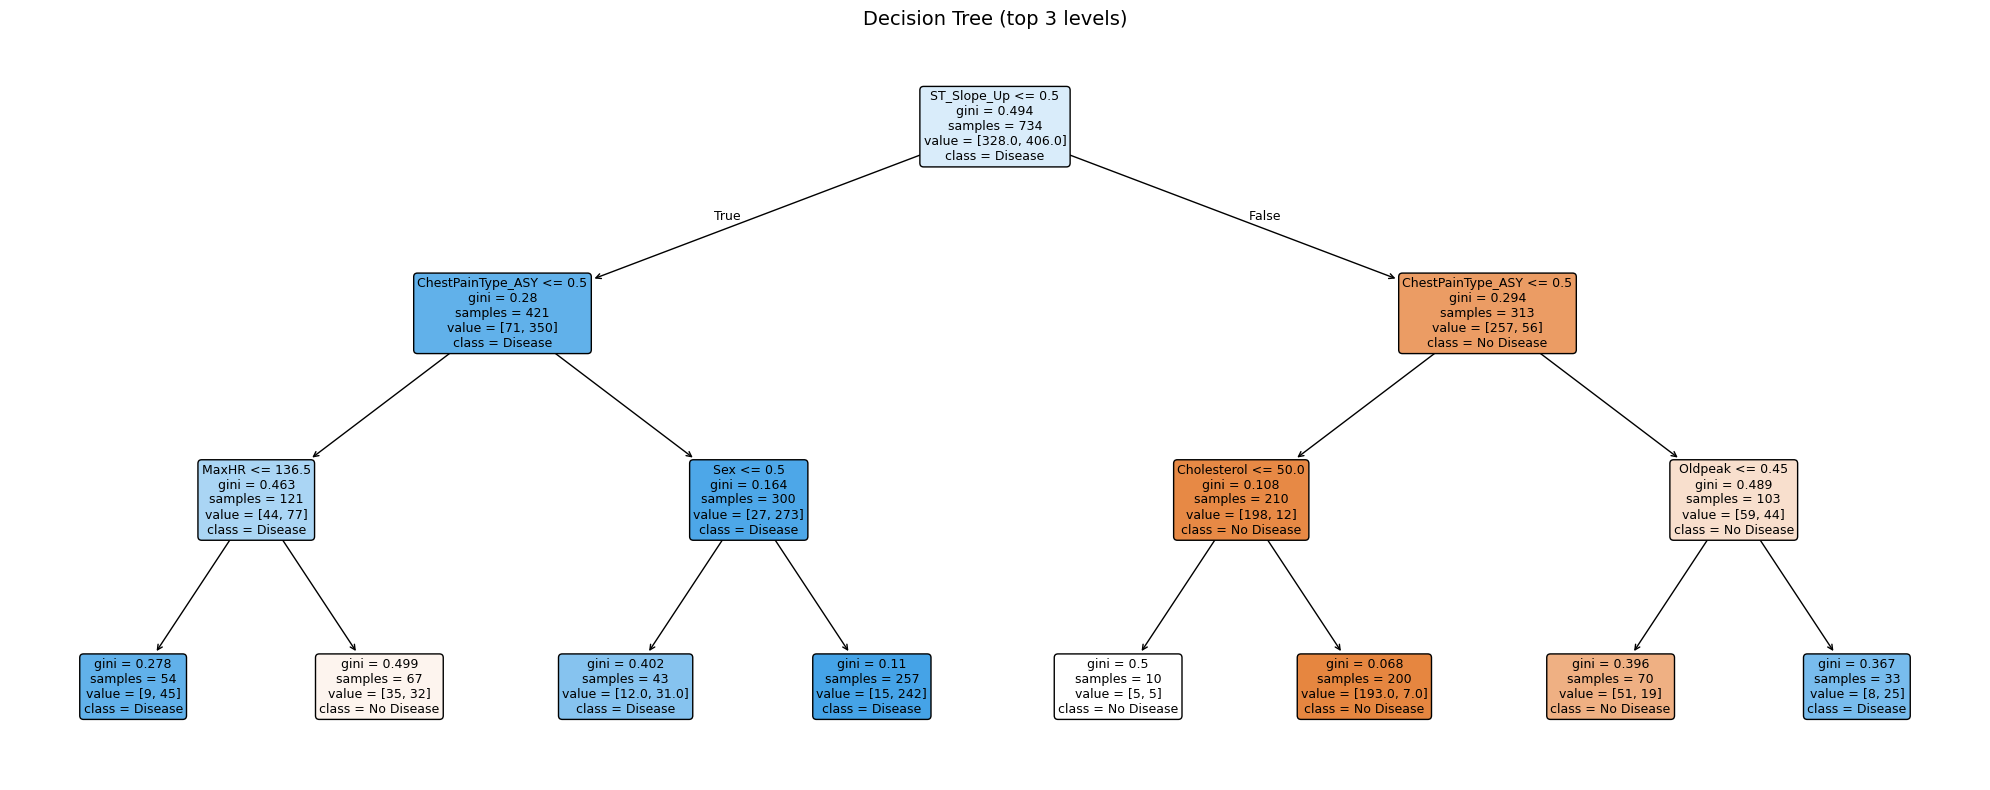

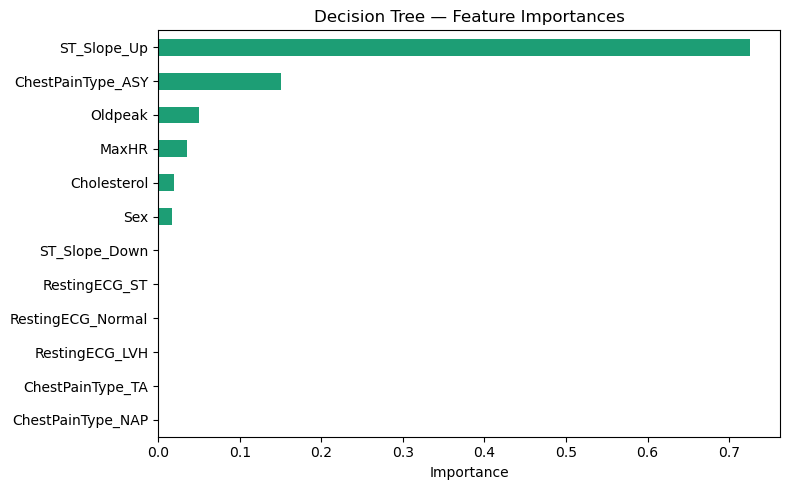

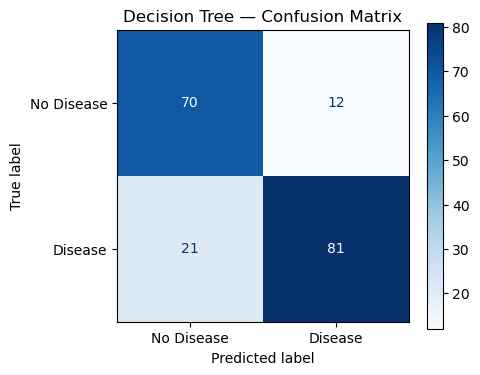

=== Linear Regression (thresholded at 0.5) ===
Accuracy : 0.8913
AUC-ROC  : 0.9271

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.84      0.87        82
     Disease       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



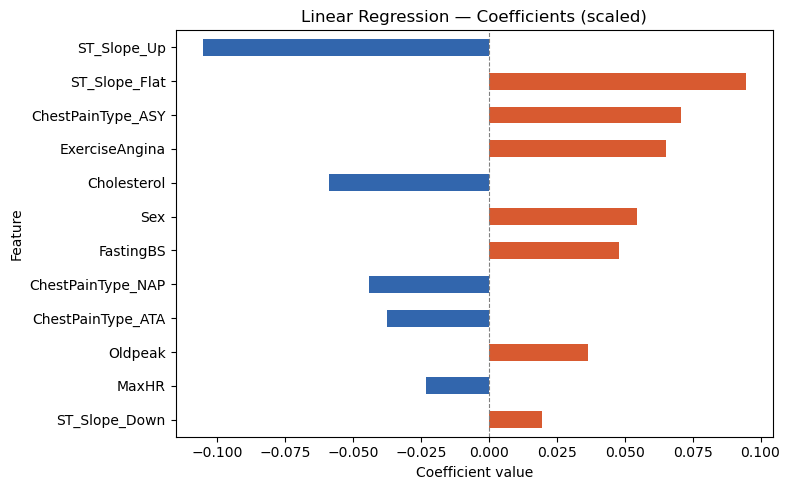

Tuned Logistic Regression Parameters: {'C': np.float64(0.05179474679231213)}
Best CV score is 0.8528


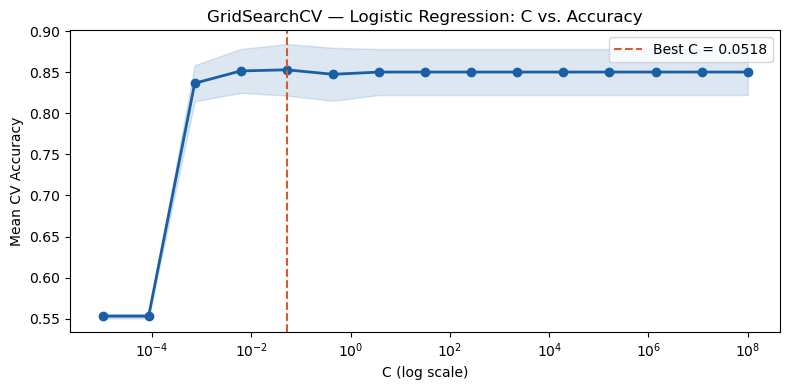

=== Logistic Regression ===
Accuracy : 0.8859
AUC-ROC  : 0.9302

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.83      0.87        82
     Disease       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



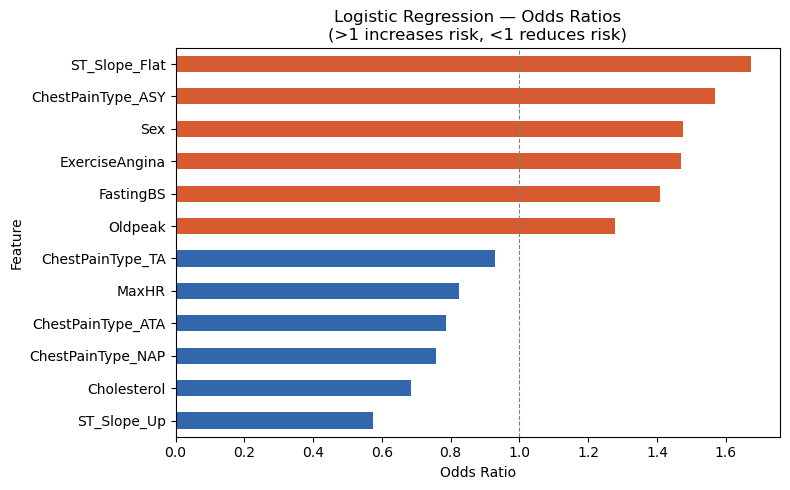

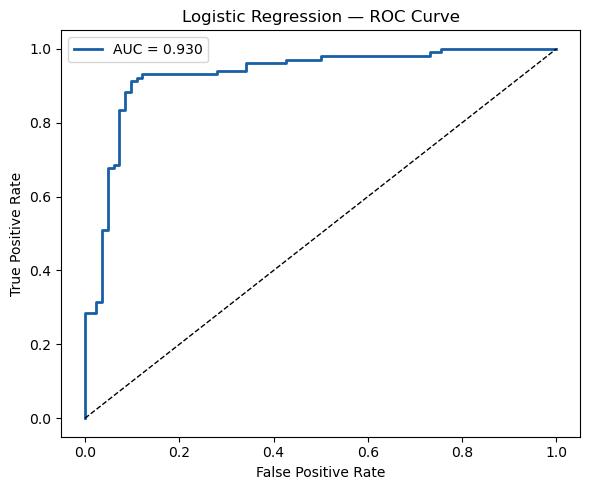

=== Gaussian Naive Bayes ===
Accuracy : 0.8804
AUC-ROC  : 0.9070

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.84      0.86        82
     Disease       0.88      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



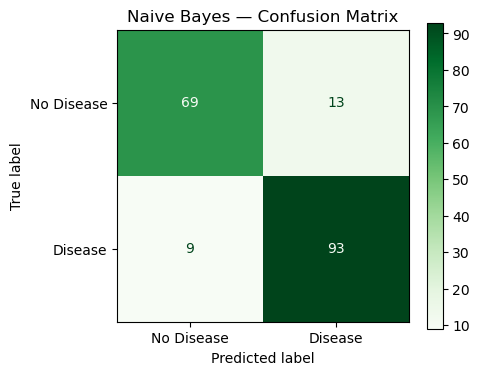

              Model  Accuracy  AUC-ROC
  Linear Regression    0.8913   0.9271
Logistic Regression    0.8859   0.9302
        Naive Bayes    0.8804   0.9070
      Decision Tree    0.8207   0.8859


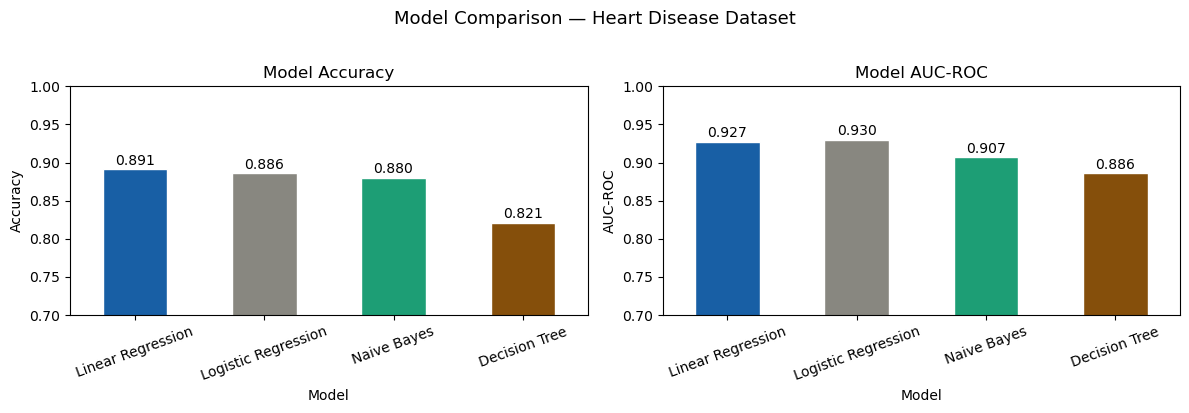

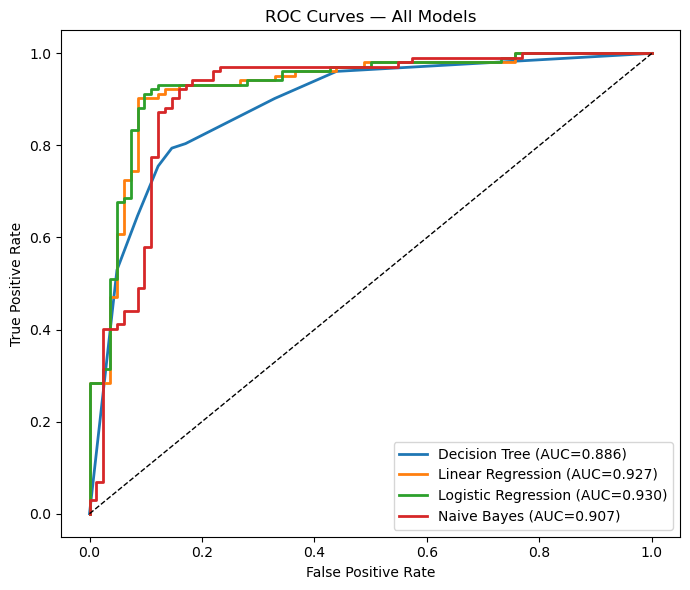

In [7]:
# %% [markdown]
# # Heart Disease Prediction — ML Models
# **Dataset:** heart.csv (918 rows, 11 features, binary target: HeartDisease)
#
# **Steps covered:**
# 1. Load & explore the dataset
# 2. Preprocessing (encoding + scaling)
# 3. Decision Tree (+ visualize the tree)
# 4. Linear Regression (baseline)
# 5. Logistic Regression
# 6. Naive Bayes
# 7. Summary comparison

# %% [markdown]
# ## 1. Imports & Load Dataset

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# %%
df = pd.read_csv('heart.csv')
print("Shape:", df.shape)
df.head()

# %% [markdown]
# ## 2. Exploratory Data Analysis

# %%
# Basic info
df.info()

# %%
# Summary statistics
df.describe()

# %%
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# %%
# Target distribution
print("HeartDisease value counts:")
print(df['HeartDisease'].value_counts())
print(f"\nClass balance: {df['HeartDisease'].mean():.1%} positive (disease)")

# %%
# Visualise target balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target count
df['HeartDisease'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#3266ad', '#D85A30'], edgecolor='white'
)
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution by class
df[df['HeartDisease'] == 0]['Age'].plot(kind='hist', alpha=0.6, label='No Disease', ax=axes[1], color='#3266ad')
df[df['HeartDisease'] == 1]['Age'].plot(kind='hist', alpha=0.6, label='Disease', ax=axes[1], color='#D85A30')
axes[1].set_title('Age Distribution by Class')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Preprocessing

# %%
# --- Encode categorical features ---

# Binary encoding
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])               # M=1, F=0
df['ExerciseAngina'] = LabelEncoder().fit_transform(df['ExerciseAngina'])  # Y=1, N=0

# One-hot encoding for multi-class categoricals
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=False)

print("Columns after encoding:")
print(df.columns.tolist())
df.head(3)

# %%
# --- Define features and target ---
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# %%
# --- Train / test split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

# %%
# --- Scale features (for linear & logistic regression) ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_s  = scaler.transform(X_test)        # apply same transform to test

# %% [markdown]
# ## 4. Decision Tree

# %% [markdown]
# ### 4a. Hyperparameter Tuning — max_depth
#
# `max_depth` controls how deep the tree can grow.
# - Too shallow → underfitting (misses patterns)
# - Too deep   → overfitting (memorises training data)
#
# We test depths 1–20 and compare train vs. test accuracy to find the sweet spot.

# %%
# Tune max_depth: compare train vs test accuracy
max_depths = range(1, 21)
train_scores = []
test_scores  = []

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf.predict(X_test)))

best_depth = max_depths[np.argmax(test_scores)]
print(f"Best max_depth by test accuracy: {best_depth}")
print(f"  Train accuracy at best depth : {train_scores[best_depth-1]:.4f}")
print(f"  Test  accuracy at best depth : {test_scores[best_depth-1]:.4f}")

# %%
# Plot train vs test accuracy across depths
plt.figure(figsize=(8, 4))
plt.plot(max_depths, train_scores, marker='o', label='Train accuracy', color='#1D9E75')
plt.plot(max_depths, test_scores,  marker='s', label='Test accuracy',  color='#D85A30')
plt.axvline(best_depth, linestyle='--', color='gray', lw=1.2, label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — max_depth Tuning (Train vs. Test)')
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4b. Cross-Validation (Stratified 5-Fold)
#
# A single train/test split can be lucky or unlucky depending on which rows end up in each set.
# Cross-validation repeats the evaluation across 5 different splits and averages the result —
# giving a much more reliable estimate of true model performance.

# %%
# 5-fold stratified cross-validation with best depth
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

cv_scores = cross_val_score(dt_best, X, y, cv=cv, scoring='accuracy')

print("=== Decision Tree — 5-Fold Cross-Validation ===")
print(f"Scores per fold : {np.round(cv_scores, 4)}")
print(f"Mean accuracy   : {cv_scores.mean():.4f}")
print(f"Std deviation   : {cv_scores.std():.4f}")

# %%
# Visualise CV fold scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='#1D9E75', edgecolor='white', width=0.5)
plt.axhline(cv_scores.mean(), color='#D85A30', linestyle='--', lw=1.5,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Decision Tree — CV Accuracy per Fold')
plt.ylim(0.70, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4c. Train final model with best max_depth

# %%
# Train with best depth found above
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42, criterion='gini')
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Decision Tree (tuned) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

# %%
# Plot the decision tree
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3    # show top 3 levels for readability
)
plt.title('Decision Tree (top 3 levels)', fontsize=14)
plt.tight_layout()
plt.show()

# %%
# Feature importances
importances = pd.Series(dt.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=True).tail(12)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='#1D9E75')
plt.title('Decision Tree — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# %%
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Linear Regression (Baseline Classifier)

# %%
# Train
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# Predict — threshold raw output at 0.5
y_raw_lr   = lr.predict(X_test_s)
y_pred_lr  = (y_raw_lr >= 0.5).astype(int)

# Evaluate
print("=== Linear Regression (thresholded at 0.5) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_raw_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Disease']))

# %%
# Top coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=True).tail(12)

plt.figure(figsize=(8, 5))
colors = ['#D85A30' if c > 0 else '#3266ad' for c in coef_df['Coefficient']]
coef_df.plot(
    kind='barh', x='Feature', y='Coefficient',
    color=colors, legend=False, ax=plt.gca()
)
plt.title('Linear Regression — Coefficients (scaled)')
plt.xlabel('Coefficient value')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Logistic Regression

# %% [markdown]
# ### 6a. Hyperparameter Tuning with GridSearchCV
#
# The key hyperparameter in Logistic Regression is **C** (inverse regularisation strength).
# - Small C → stronger regularisation → simpler model (underfitting risk)
# - Large C → weaker regularisation → more complex model (overfitting risk)
#
# GridSearchCV tries every value in `param_grid` using 5-fold cross-validation
# and picks the C that gives the best mean accuracy across all folds.

# %%
# Define the C search space: 15 values from 10⁻⁵ to 10⁸ on a log scale
c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space}

logreg_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
logreg_cv.fit(X_train_s, y_train)

print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Best CV score is {:.4f}".format(logreg_cv.best_score_))

# %%
# Visualise CV accuracy across all C values
cv_results = logreg_cv.cv_results_

plt.figure(figsize=(8, 4))
plt.semilogx(c_space, cv_results['mean_test_score'], marker='o', color='#185FA5', lw=2)
plt.fill_between(
    c_space,
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.15, color='#185FA5'
)
plt.axvline(logreg_cv.best_params_['C'], color='#D85A30', linestyle='--', lw=1.5,
            label=f"Best C = {logreg_cv.best_params_['C']:.4f}")
plt.xlabel('C (log scale)')
plt.ylabel('Mean CV Accuracy')
plt.title('GridSearchCV — Logistic Regression: C vs. Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 6b. Train final model with best C

# %%
# Train — use the best C found by GridSearchCV
best_C = logreg_cv.best_params_['C']
log_reg = LogisticRegression(max_iter=1000, C=best_C, random_state=42)
log_reg.fit(X_train_s, y_train)

# Predict
y_pred_log  = log_reg.predict(X_test_s)
y_prob_log  = log_reg.predict_proba(X_test_s)[:, 1]

# Evaluate
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['No Disease', 'Disease']))

# %%
# Odds ratios (exponentiated coefficients)
odds = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Odds Ratio', ascending=True)

top_odds = pd.concat([odds.head(6), odds.tail(6)])

plt.figure(figsize=(8, 5))
colors = ['#D85A30' if o > 1 else '#3266ad' for o in top_odds['Odds Ratio']]
top_odds.plot(
    kind='barh', x='Feature', y='Odds Ratio',
    color=colors, legend=False, ax=plt.gca()
)
plt.axvline(1, color='gray', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression — Odds Ratios\n(>1 increases risk, <1 reduces risk)')
plt.xlabel('Odds Ratio')
plt.tight_layout()
plt.show()

# %%
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
auc_score = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Naive Bayes

# %%
# Train — GaussianNB does not need scaled data
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Gaussian Naive Bayes ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gnb):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_gnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=['No Disease', 'Disease']))

# %%
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnb,
    display_labels=['No Disease', 'Disease'],
    cmap='Greens', ax=ax
)
ax.set_title('Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Model Comparison Summary

# %%
# Collect all results
results = {
    'Model': [
        'Decision Tree',
        'Linear Regression',
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_gnb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_raw_lr),
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_gnb)
    ]
}

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df[['Accuracy', 'AUC-ROC']] = results_df[['Accuracy', 'AUC-ROC']].round(4)
print(results_df.to_string(index=False))

# %%
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#185FA5', '#888780', '#1D9E75', '#854F0B']

results_df.plot(
    kind='bar', x='Model', y='Accuracy',
    ax=axes[0], color=colors, legend=False, edgecolor='white'
)
axes[0].set_title('Model Accuracy')
axes[0].set_ylim(0.70, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)
for bar in axes[0].patches:
    axes[0].annotate(
        f'{bar.get_height():.3f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002),
        ha='center', va='bottom', fontsize=10
    )

results_df.plot(
    kind='bar', x='Model', y='AUC-ROC',
    ax=axes[1], color=colors, legend=False, edgecolor='white'
)
axes[1].set_title('Model AUC-ROC')
axes[1].set_ylim(0.70, 1.0)
axes[1].set_ylabel('AUC-ROC')
axes[1].tick_params(axis='x', rotation=20)
for bar in axes[1].patches:
    axes[1].annotate(
        f'{bar.get_height():.3f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002),
        ha='center', va='bottom', fontsize=10
    )

plt.suptitle('Model Comparison — Heart Disease Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# %%
# ROC curves for all models on one plot
plt.figure(figsize=(7, 6))

for name, y_prob in [
    ('Decision Tree',       y_prob_dt),
    ('Linear Regression',   y_raw_lr),
    ('Logistic Regression', y_prob_log),
    ('Naive Bayes',         y_prob_gnb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Summary
#
# | Model               | Best for                          | Needs scaling |
# |---------------------|-----------------------------------|---------------|
# | Decision Tree       | Interpretability, rule extraction | No            |
# | Linear Regression   | Quick baseline only               | Yes           |
# | Logistic Regression | Best accuracy + probabilities     | Yes           |
# | Naive Bayes         | Fast, small data, good baseline   | No            |
#
# **Key takeaway:** For clinical use, prioritise **Recall** for the Disease class —
# a missed diagnosis (false negative) is more costly than a false alarm.
# Logistic Regression typically gives the best balance of accuracy and interpretability
# on this dataset.